<a href="https://colab.research.google.com/github/mgadisa51/Machine_Learning/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

1.**Importing**

In [ ]:
df = pd.read_csv('sample_data/Student.csv')

In [ ]:
df.head()

,Student_ID,Gender,Attendance_Rate_Percent,Participation_Score_1_10,Study_Hours_Weekly,Parent_Involvement,Teaching_Method,Midterm_Score,Final_Score
0,STU_001,Male,99.1,9.2,7.3,Medium,Small-Group-Roles,63.2,79.7
1,STU_002,Female,93.3,3.2,8.9,High,Small-Group-Roles,54.1,67.6
2,STU_003,Male,98.2,2.3,17.3,Medium,Small-Group-Roles,65.6,76.4
3,STU_004,Male,96.8,5.4,7.7,Low,Standard,58.4,65.7
4,STU_005,Male,87.9,9.9,5.1,Low,Think-Pair-Share,61.5,72.4


In [ ]:
df.tail()

,Student_ID,Gender,Attendance_Rate_Percent,Participation_Score_1_10,Study_Hours_Weekly,Parent_Involvement,Teaching_Method,Midterm_Score,Final_Score
95,STU_096,Female,71.1,9.4,13.1,High,Think-Pair-Share,73.7,79.6
96,STU_097,Female,88.3,4.9,13.4,High,Think-Pair-Share,63.4,72.0
97,STU_098,Female,85.1,9.7,2.8,High,Small-Group-Roles,57.9,62.6
98,STU_099,Female,71.5,9.7,8.7,Medium,Standard,54.4,68.2
99,STU_100,Male,78.4,8.7,13.3,Low,Small-Group-Roles,59.2,72.1


In [ ]:
df.shape

(100, 9)

**2.Data Cleaning**

In [ ]:
df.describe()

In [ ]:
df.isnull().sum()

,0
Student_ID,0
Gender,0
Attendance_Rate_Percent,0
Participation_Score_1_10,0
Study_Hours_Weekly,0
Parent_Involvement,0
Teaching_Method,0
Midterm_Score,0
Final_Score,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
df['Parent_Involvement'] = le.fit_transform(df['Parent_Involvement'])
df['Teaching_Method'] = le.fit_transform(df['Teaching_Method'])

In [ ]:
X = df.drop(['Student_ID', 'Final_Score'], axis=1)
y = df['Final_Score']

**3.Split the Data into Training/Test Set**

In [ ]:
X = df.drop(columns=['Final_Score', 'Student_ID'])
X

,Gender,Attendance_Rate_Percent,Participation_Score_1_10,Study_Hours_Weekly,Parent_Involvement,Teaching_Method,Midterm_Score
0,1,99.1,9.2,7.3,2,0,63.2
1,0,93.3,3.2,8.9,0,0,54.1
2,1,98.2,2.3,17.3,2,0,65.6
3,1,96.8,5.4,7.7,1,1,58.4
4,1,87.9,9.9,5.1,1,2,61.5
...,...,...,...,...,...,...,...
95,0,71.1,9.4,13.1,0,2,73.7
96,0,88.3,4.9,13.4,0,2,63.4
97,0,85.1,9.7,2.8,0,0,57.9
98,0,71.5,9.7,8.7,2,1,54.4


In [ ]:
y = df['Final_Score']
y

,Final_Score
0,79.7
1,67.6
2,76.4
3,65.7
4,72.4
...,...
95,79.6
96,72.0
97,62.6
98,68.2


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

4.Create (Import) a Model


In [ ]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

**5.Prediction**

In [ ]:
predictions = model.predict(X_test)

**6.Evaluation**

In [ ]:
print(f"Accuracy (R2 Score): {r2_score(y_test, predictions):.2f}")
print(f"Average Error (MAE): {mean_absolute_error(y_test, predictions):.2f}")

Accuracy (R2 Score): 0.80
Average Error (MAE): 4.17


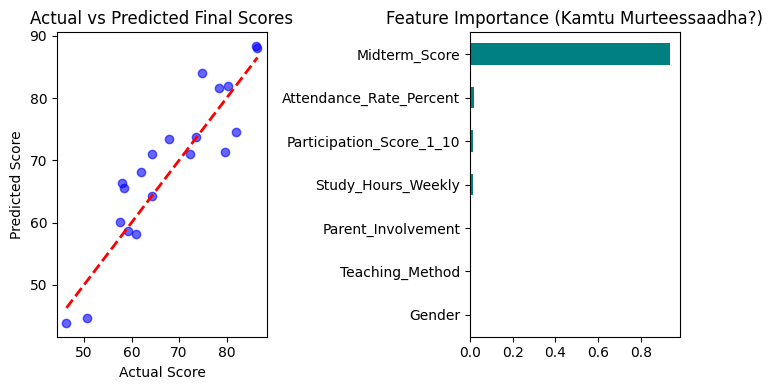

In [42]:
plt.figure(figsize=(7, 4))

# Giraafii 1: Actual vs Predicted
plt.subplot(1, 2, 1)
plt.scatter(y_test, predictions, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Score')
plt.ylabel('Predicted Score')
plt.title('Actual vs Predicted Final Scores')

# Giraafii 2: Feature Importance
plt.subplot(1, 2, 2)
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values()
importances.plot(kind='barh', color='teal')
plt.title('Feature Importance (Kamtu Murteessaadha?)')

plt.tight_layout()
plt.show()